# 🛒 Olist Brazilian E-Commerce — Data Analysis
## Habuild Data Analyst Case Study

---

| | |
|---|---|
| **Dataset** | Olist Brazilian E-Commerce Public Dataset (Kaggle) |
| **Period** | September 2016 – October 2018 |
| **Scale** | ~100,000 orders, 9 relational tables |
| **Goal** | Customer behavior, delivery performance, growth insights |

---

### Notebook Structure
1. [Setup & Data Loading](#1)
2. [Data Cleaning & Feature Engineering](#2)
3. [Exploratory Data Analysis (EDA)](#3)
   - 3.1 Headline Metrics
   - 3.2 Growth Trends
   - 3.3 Temporal Patterns *(non-intuitive finding)*
   - 3.4 Geography
   - 3.5 Product Categories
   - 3.6 Payment Behaviour
   - 3.7 Delivery Performance
   - 3.8 Review Score Analysis
   - 3.9 RFM Segmentation
   - 3.10 Cohort Retention
4. [Hypothesis Testing](#4)
   - H1: Late delivery → lower review scores
   - H2: Credit card users spend more than boleto users
5. [Additional Pattern: Price vs Satisfaction](#5)
6. [Actionables & Further Exploration](#6)
7. [LLM Disclosure (Appendix)](#7)

---
> **LLM Disclosure:** Claude (Anthropic) was used for Python/pandas/scipy syntax help,  
> chart styling, and notebook formatting. All hypotheses, EDA questions, and  
> written interpretations are the analyst's own work.


## 1. Setup & Data Loading <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency, kruskal
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

# ── Notebook display settings ──────────────────────────────
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_rows', 60)

# ── Plot theme ─────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#F8F9FA',
    'axes.facecolor':    '#FFFFFF',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.35,
    'grid.linestyle':    '--',
    'axes.labelsize':    11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'font.family':       'DejaVu Sans',
})

PALETTE = ['#2E75B6','#ED7D31','#70AD47','#C00000','#7030A0','#00B0F0']
sns.set_palette(PALETTE)

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
import os

# ── Data path ─────────────────────────────────────────────────────────────────
# Set this to wherever your 9 Olist CSV files live.
# Examples:
#   Windows : DATA_PATH = r"E:\ecommerce\data"
#   Mac/Linux: DATA_PATH = "data/"
DATA_PATH = r"E:\ecommerce\data"   # <-- update if needed

# File name map (exact Kaggle filenames)
FILE_MAP = {
    "customers"     : "olist_customers_dataset.csv",
    "orders"        : "olist_orders_dataset.csv",
    "order_items"   : "olist_order_items_dataset.csv",
    "products"      : "olist_products_dataset.csv",
    "reviews"       : "olist_order_reviews_dataset.csv",
    "payments"      : "olist_order_payments_dataset.csv",
    "sellers"       : "olist_sellers_dataset.csv",
    "geolocation"   : "olist_geolocation_dataset.csv",
    "category_trans": "product_category_name_translation.csv",
}

def load(key):
    fpath = os.path.join(DATA_PATH, FILE_MAP[key])
    if not os.path.exists(fpath):
        raise FileNotFoundError(f"Not found: {fpath}\nCheck DATA_PATH above.")
    # utf-8-sig strips the BOM (﻿) present in the category translation CSV
    enc = "utf-8-sig" if key == "category_trans" else "utf-8"
    return pd.read_csv(fpath, encoding=enc)

customers      = load("customers")
orders         = load("orders")
order_items    = load("order_items")
products       = load("products")
reviews        = load("reviews")
payments       = load("payments")
sellers        = load("sellers")
geolocation    = load("geolocation")
category_trans = load("category_trans")

# Verify the category translation loaded cleanly (no BOM in column name)
assert category_trans.columns[0] == "product_category_name", \
    f"BOM still present! Got: {category_trans.columns[0]!r}"

# Quick shape check
tables = {
    "customers"     : customers,
    "orders"        : orders,
    "order_items"   : order_items,
    "products"      : products,
    "reviews"       : reviews,
    "payments"      : payments,
    "sellers"       : sellers,
    "geolocation"   : geolocation,
    "category_trans": category_trans,
}
print(f"{'Table':<20} {'Rows':>10} {'Cols':>6}")
print("-" * 38)
for name, df in tables.items():
    print(f"{name:<20} {df.shape[0]:>10,} {df.shape[1]:>6}")
print("\n✅ All 9 files loaded successfully!")
print(f"   category_trans columns: {list(category_trans.columns)}")


Table                      Rows   Cols
--------------------------------------
customers                99,441      5
orders                   99,441      8
order_items             112,650      7
products                 32,951      9
reviews                  99,224      7
payments                103,886      5
sellers                   3,095      4
geolocation           1,000,163      5
category_trans               71      2

✅ All 9 files loaded successfully!
   category_trans columns: ['product_category_name', 'product_category_name_english']


## 2. Data Cleaning & Feature Engineering <a id='2'></a>

### Cleaning steps
- Parse all timestamp columns
- De-duplicate reviews (keep the latest answer per order)
- Aggregate payments to order level (sum value, modal payment type)
- Compute delivery KPIs: `delivery_days`, `delay_days`, `is_late`
- Extract time features: month, hour, day-of-week


In [3]:
# ── 2.1 Parse timestamps ──────────────────────────────────────────────────────
TS_COLS = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]
for col in TS_COLS:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

print("✅ Timestamps parsed")
print(f"   Date range: {orders['order_purchase_timestamp'].min().date()} "
      f"→ {orders['order_purchase_timestamp'].max().date()}")
print(f"   Orders with no delivery date: "
      f"{orders['order_delivered_customer_date'].isna().sum():,}")
print(f"   Orders with no estimated date: "
      f"{orders['order_estimated_delivery_date'].isna().sum():,}")


✅ Timestamps parsed
   Date range: 2016-09-04 → 2018-10-17
   Orders with no delivery date: 2,965
   Orders with no estimated date: 0


In [4]:
# ── 2.2 Clean reviews (keep latest per order) ────────────────────────────────
# review_answer_timestamp may not exist in all dataset versions
if 'review_answer_timestamp' in reviews.columns:
    reviews_clean = (reviews
        .sort_values('review_answer_timestamp', na_position='first')
        .drop_duplicates('order_id', keep='last')
        [['order_id', 'review_score']]
    )
else:
    reviews_clean = reviews.drop_duplicates('order_id', keep='last')[['order_id','review_score']]

print(f"✅ Reviews: {len(reviews):,} rows → {len(reviews_clean):,} after dedup")

# ── 2.3 Aggregate payments to order level ────────────────────────────────────
payments_clean = (payments
    .groupby('order_id', as_index=False)
    .agg(
        payment_value        = ('payment_value',        'sum'),
        payment_type         = ('payment_type',         lambda x: x.mode()[0]),
        payment_installments = ('payment_installments', 'max'),
        n_payment_methods    = ('payment_sequential',   'count'),
    )
)
print(f"✅ Payments aggregated: {len(payments_clean):,} orders")


✅ Reviews: 99,224 rows → 98,673 after dedup
✅ Payments aggregated: 99,440 orders


In [5]:
# ── 2.4 Order-level item aggregates ──────────────────────────────────────────
# Guard: product_weight_g may not exist in all versions
weight_col = ['product_weight_g'] if 'product_weight_g' in products.columns else []

items_with_cat = (order_items
    .merge(products[['product_id', 'product_category_name'] + weight_col],
           on='product_id', how='left')
    .merge(category_trans, on='product_category_name', how='left')
)

agg_dict = {
    'total_items_value': ('price',          'sum'),
    'total_freight'    : ('freight_value',  'sum'),
    'n_items'          : ('order_item_id',  'count'),
    'main_category'    : ('product_category_name_english',
                          lambda x: x.mode()[0] if x.notna().any() else np.nan),
}
if weight_col:
    agg_dict['avg_weight_g'] = ('product_weight_g', 'mean')

order_agg = items_with_cat.groupby('order_id', as_index=False).agg(**agg_dict)
print(f"✅ Order item aggregates: {len(order_agg):,} orders")
print(f"   Columns: {list(order_agg.columns)}")


✅ Order item aggregates: 98,666 orders
   Columns: ['order_id', 'total_items_value', 'total_freight', 'n_items', 'main_category', 'avg_weight_g']


In [6]:
# ── 2.5 Master merge ─────────────────────────────────────────────────────────
master = (orders
    .merge(customers,       on='customer_id', how='left')
    .merge(payments_clean,  on='order_id',    how='left')
    .merge(reviews_clean,   on='order_id',    how='left')
    .merge(order_agg,       on='order_id',    how='left')
)

# ── 2.6 Delivery KPIs ─────────────────────────────────────────────────────────
delivered_mask = master['order_status'] == 'delivered'

master.loc[delivered_mask, 'delivery_days'] = (
    (master.loc[delivered_mask, 'order_delivered_customer_date'] -
     master.loc[delivered_mask, 'order_purchase_timestamp']).dt.days
)
master.loc[delivered_mask, 'delay_days'] = (
    (master.loc[delivered_mask, 'order_delivered_customer_date'] -
     master.loc[delivered_mask, 'order_estimated_delivery_date']).dt.days
)
master['is_late'] = master['delay_days'].fillna(0) > 0

# Remove implausible delivery times
master = master[~(delivered_mask & master['delivery_days'].notna() & (master['delivery_days'] < 0))]
master = master[~(delivered_mask & master['delivery_days'].notna() & (master['delivery_days'] > 120))]

# ── 2.7 Time features ─────────────────────────────────────────────────────────
master['period']     = master['order_purchase_timestamp'].dt.to_period('M')
master['year']       = master['order_purchase_timestamp'].dt.year
master['month']      = master['order_purchase_timestamp'].dt.month
master['hour']       = master['order_purchase_timestamp'].dt.hour
master['dow']        = master['order_purchase_timestamp'].dt.day_name()
master['dow_num']    = master['order_purchase_timestamp'].dt.dayofweek
master['is_weekend'] = master['dow_num'].isin([5, 6])

print(f"✅ Master table shape: {master.shape}")
print(f"   Delivered orders : {delivered_mask.sum():,}")
print(f"   Canceled orders  : {(master['order_status']=='canceled').sum():,}")
print(f"   Late deliveries  : {master['is_late'].sum():,}  "
      f"({master['is_late'].mean()*100:.1f}%)")


✅ Master table shape: (99398, 32)
   Delivered orders : 96,478
   Canceled orders  : 625
   Late deliveries  : 6,491  (6.5%)


In [7]:
# ── 2.8 Data quality summary ─────────────────────────────────────────────────
key_cols = [c for c in ['payment_value','review_score','delivery_days',
                         'is_late','n_items','main_category','customer_state']
            if c in master.columns]
null_df = master[key_cols].isnull().sum().rename('nulls').to_frame()
null_df['null_%'] = (null_df['nulls'] / len(master) * 100).round(1)
print("Null check on key columns:")
print(null_df)
print(f"\nMaster table: {master.shape[0]:,} rows × {master.shape[1]} columns")


Null check on key columns:
                nulls  null_%
payment_value       1    0.00
review_score      766    0.80
delivery_days    2971    3.00
is_late             0    0.00
n_items           775    0.80
main_category    2183    2.20
customer_state      0    0.00

Master table: 99,398 rows × 32 columns


## 3. Exploratory Data Analysis <a id='3'></a>

### 3.1 Headline Business Metrics

In [8]:
delivered = master[master['order_status'] == 'delivered'].copy()

metrics = {
    'Total Orders':            master['order_id'].nunique(),
    'Unique Customers':        master['customer_unique_id'].nunique(),
    'Total Revenue (R$)':      master['payment_value'].sum(),
    'Avg Order Value (R$)':    master.groupby('order_id')['payment_value'].first().mean(),
    'Median Order Value (R$)': master.groupby('order_id')['payment_value'].first().median(),
    'Delivery Rate':           f"{(master['order_status']=='delivered').mean()*100:.1f}%",
    'Cancellation Rate':       f"{(master['order_status']=='canceled').mean()*100:.1f}%",
    'Late Delivery Rate':      f"{master['is_late'].mean()*100:.1f}%",
    'Avg Delivery Days':       f"{delivered['delivery_days'].mean():.1f}",
    'Median Delivery Days':    f"{delivered['delivery_days'].median():.1f}",
    'Avg Review Score':        f"{master['review_score'].mean():.2f} / 5",
    'Credit Card Share':       f"{(master['payment_type']=='credit_card').mean()*100:.1f}%",
    'Multi-item Orders':       f"{(master['n_items'] > 1).mean()*100:.1f}%",
}

print(f"{'Metric':<30} {'Value':>20}")
print("─" * 52)
for k, v in metrics.items():
    vfmt = f"R${v:,.2f}" if isinstance(v, float) else (f"{v:,}" if isinstance(v, int) else str(v))
    print(f"{k:<30} {vfmt:>20}")

Metric                                        Value
────────────────────────────────────────────────────
Total Orders                                 99,398
Unique Customers                             96,053
Total Revenue (R$)                  R$15,996,350.98
Avg Order Value (R$)                       R$160.93
Median Order Value (R$)                    R$105.29
Delivery Rate                                 97.0%
Cancellation Rate                              0.6%
Late Delivery Rate                             6.5%
Avg Delivery Days                              12.0
Median Delivery Days                           10.0
Avg Review Score                           4.09 / 5
Credit Card Share                             76.6%
Multi-item Orders                              9.9%


### 3.2 Order Volume & Revenue Growth

Monthly order volume grew ~150% from Jan 2017 to mid-2018.  
The October 2018 cliff is a **data artifact** (dataset ends mid-month), not a demand collapse.


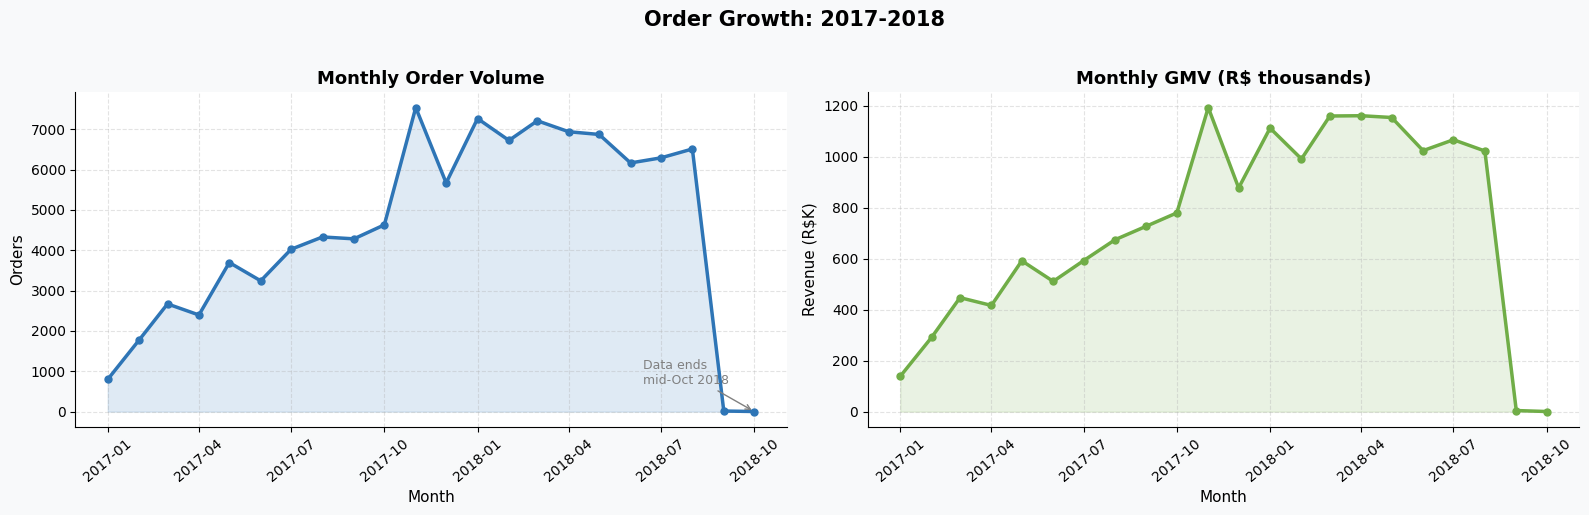

Orders 2017:          45,067
Orders 2018 (Jan-Sep): 53,998
YoY growth (Jan-Sep comparable): 20%


In [9]:
monthly = (master
    .groupby('period')
    .agg(n_orders=('order_id','nunique'), revenue=('payment_value','sum'))
    .reset_index()
)
monthly['month_dt'] = monthly['period'].dt.to_timestamp()
monthly = monthly[monthly['month_dt'] >= '2017-01-01'].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Order Growth: 2017-2018', fontsize=15, fontweight='bold', y=1.02)

# Orders
ax = axes[0]
ax.fill_between(monthly['month_dt'], monthly['n_orders'], alpha=0.15, color=PALETTE[0])
ax.plot(monthly['month_dt'], monthly['n_orders'], color=PALETTE[0], lw=2.5, marker='o', ms=5)
ax.set_title('Monthly Order Volume')
ax.set_xlabel('Month'); ax.set_ylabel('Orders')
ax.tick_params(axis='x', rotation=40)

# Annotate Oct 2018 cliff  -- use \n inside a double-quoted string
last = monthly.iloc[-1]
ax.annotate(
    "Data ends\nmid-Oct 2018",
    xy=(last['month_dt'], last['n_orders']),
    xytext=(-80, 20),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9,
    color='gray'
)

# Revenue
ax = axes[1]
ax.fill_between(monthly['month_dt'], monthly['revenue']/1000, alpha=0.15, color=PALETTE[2])
ax.plot(monthly['month_dt'], monthly['revenue']/1000, color=PALETTE[2], lw=2.5, marker='o', ms=5)
ax.set_title('Monthly GMV (R$ thousands)')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue (R$K)')
ax.tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.show()

# YoY growth
y2017 = monthly[monthly['month_dt'].dt.year == 2017]['n_orders'].sum()
y2018 = monthly[(monthly['month_dt'].dt.year == 2018) &
                (monthly['month_dt'].dt.month < 10)]['n_orders'].sum()
print(f"Orders 2017:          {y2017:,}")
print(f"Orders 2018 (Jan-Sep): {y2018:,}")
print(f"YoY growth (Jan-Sep comparable): {(y2018-y2017)/y2017*100:.0f}%")


### 3.3 Temporal Patterns ⚡ *(Non-Intuitive Finding)*

**Expected:** Heavy midnight browsing (like Netflix-era impulse shopping).  
**Actual:** Orders peak firmly at **10am–4pm** on business days — customers are shopping during work hours.  
**Day-of-week:** Unlike Western e-commerce (weekend spikes), Olist shows flat volume across all 7 days.  
This implies **need-based, deliberate purchasing**, not recreational browsing.


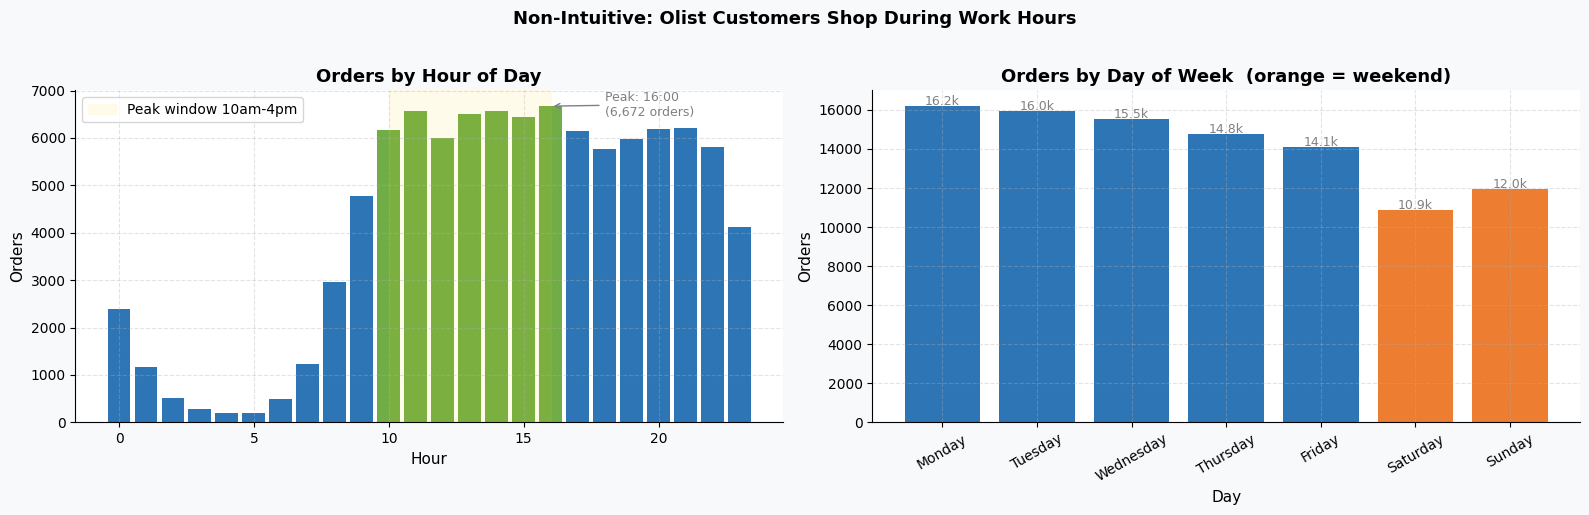

Weekday avg orders: 15,312
Weekend avg orders: 11,420  (delta = -25.4%)


In [10]:
DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

hourly  = master.groupby('hour')['order_id'].count()
dow_cnt = master.groupby('dow')['order_id'].count().reindex(DOW_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Non-Intuitive: Olist Customers Shop During Work Hours',
             fontsize=13, fontweight='bold', y=1.02)

# Hour
ax = axes[0]
bar_colors = [PALETTE[2] if 10 <= h <= 16 else PALETTE[0] for h in hourly.index]
ax.bar(hourly.index, hourly.values, color=bar_colors, edgecolor='none', width=0.85)
ax.axvspan(10, 16, alpha=0.08, color='gold', label='Peak window 10am-4pm')
ax.set_title('Orders by Hour of Day')
ax.set_xlabel('Hour'); ax.set_ylabel('Orders')
ax.legend()

# Annotate peak — build label separately to avoid f-string + \n conflict
peak_h     = hourly.idxmax()
peak_label = "Peak: {}:00\n({:,} orders)".format(peak_h, hourly.max())
ax.annotate(
    peak_label,
    xy=(peak_h, hourly.max()),
    xytext=(peak_h + 2, hourly.max() - 200),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9,
    color='gray'
)

# DoW
ax = axes[1]
dow_colors = [PALETTE[1] if d in ['Saturday','Sunday'] else PALETTE[0] for d in DOW_ORDER]
ax.bar(DOW_ORDER, dow_cnt.values, color=dow_colors, edgecolor='none')
ax.set_title('Orders by Day of Week  (orange = weekend)')
ax.set_xlabel('Day'); ax.set_ylabel('Orders')
ax.tick_params(axis='x', rotation=30)
for i, v in enumerate(dow_cnt.values):
    ax.text(i, v + 50, '{:.1f}k'.format(v/1000), ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

wd_avg = dow_cnt[['Monday','Tuesday','Wednesday','Thursday','Friday']].mean()
we_avg = dow_cnt[['Saturday','Sunday']].mean()
print(f"Weekday avg orders: {wd_avg:,.0f}")
print(f"Weekend avg orders: {we_avg:,.0f}  (delta = {(we_avg-wd_avg)/wd_avg*100:+.1f}%)")


### 3.4 Geographic Distribution

São Paulo (SP) accounts for ~43% of all customers — nearly as much as the next 5 states combined.  
Northern states (AM, PA, MA, TO) are dramatically under-represented relative to their populations → **untapped market**.


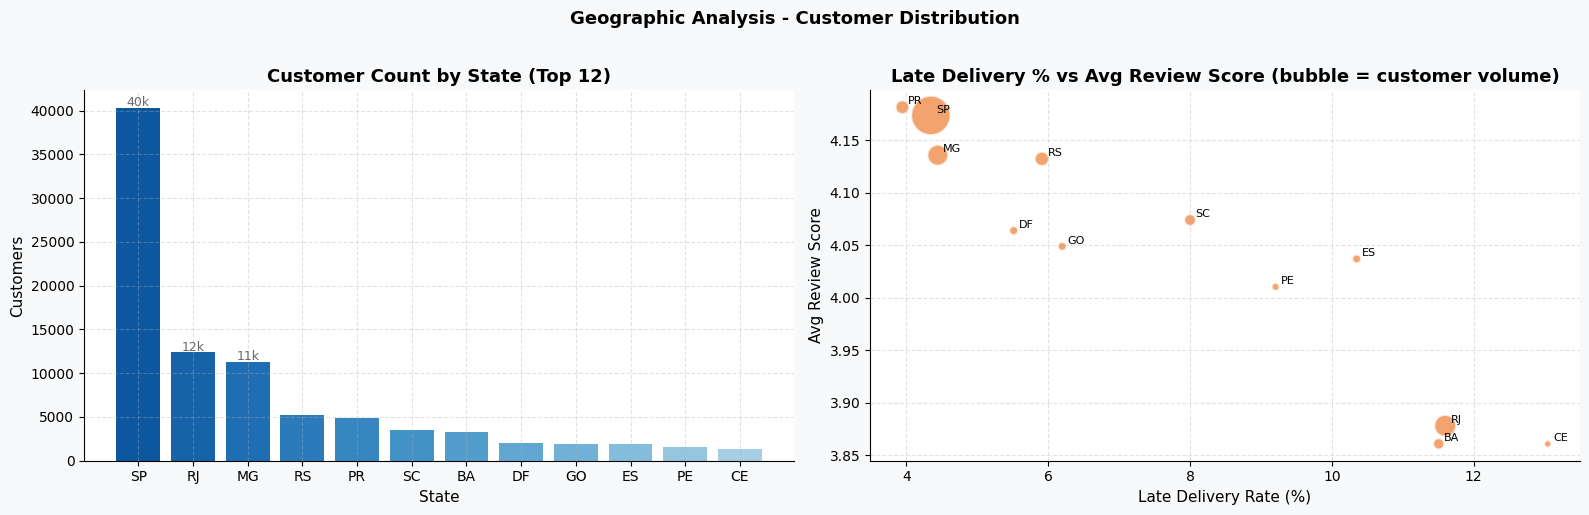

State performance summary (top 10 by revenue):
                n_customers  total_revenue  avg_score  late_%
customer_state                                               
SP                    40296   5,996,698.31       4.17    4.35
RJ                    12379   2,142,183.53       3.88   11.60
MG                    11257   1,871,120.93       4.14    4.44
RS                     5275     890,376.60       4.13    5.91
PR                     4882     811,156.38       4.18    3.94
SC                     3534     623,086.43       4.07    8.00
BA                     3269     613,747.75       3.86   11.51
DF                     2075     355,141.08       4.06    5.51
GO                     1949     349,294.71       4.05    6.20
ES                     1960     325,371.53       4.04   10.35


In [11]:
state_stats = (master
    .groupby('customer_state')
    .agg(
        n_customers   = ('customer_unique_id', 'nunique'),
        total_revenue = ('payment_value',      'sum'),
        avg_score     = ('review_score',        'mean'),
        late_pct      = ('is_late',             'mean'),
    )
    .sort_values('total_revenue', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Geographic Analysis - Customer Distribution',
             fontsize=13, fontweight='bold', y=1.02)

top12 = state_stats.head(12)

# Left: bar chart of customer count by state
ax = axes[0]
colors_bar = plt.cm.Blues(np.linspace(0.35, 0.85, len(top12)))[::-1]
bars = ax.bar(top12.index, top12['n_customers'], color=colors_bar, edgecolor='none')
ax.set_title('Customer Count by State (Top 12)')
ax.set_xlabel('State'); ax.set_ylabel('Customers')
for bar in bars[:3]:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        '{:.0f}k'.format(bar.get_height() / 1000),
        ha='center', fontsize=9, color='dimgray'
    )

# Right: scatter — late rate vs avg score, bubble = customer volume
ax = axes[1]
ax.scatter(
    top12['late_pct'] * 100,
    top12['avg_score'],
    s=top12['n_customers'] / top12['n_customers'].max() * 800,
    c=PALETTE[1], alpha=0.7, edgecolors='white', lw=1.5
)
for _, row in top12.iterrows():
    ax.annotate(
        row.name,
        (row['late_pct'] * 100, row['avg_score']),
        textcoords='offset points', xytext=(4, 2), fontsize=8
    )
# Title split across two lines using set_title with explicit newline-free approach
ax.set_title('Late Delivery % vs Avg Review Score (bubble = customer volume)')
ax.set_xlabel('Late Delivery Rate (%)'); ax.set_ylabel('Avg Review Score')

plt.tight_layout()
plt.show()

print("State performance summary (top 10 by revenue):")
print(
    state_stats.head(10)[['n_customers','total_revenue','avg_score','late_pct']]
    .assign(late_pct=lambda x: x['late_pct'] * 100)
    .rename(columns={'late_pct': 'late_%'})
    .round(2)
)


### 3.5 Product Categories

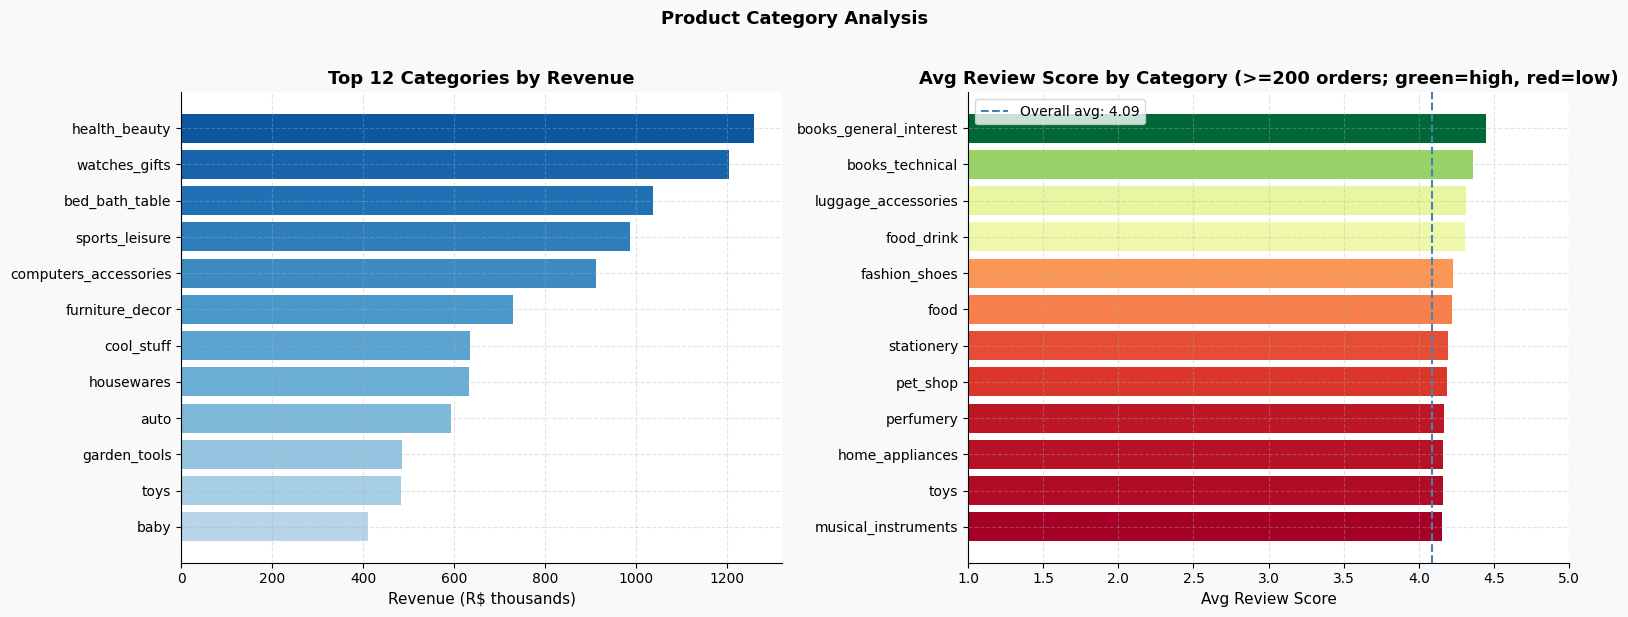

Top 5 highest-rated categories:
                               avg_score  n_orders  avg_price
product_category_name_english                                
books_general_interest              4.45       512      84.73
books_technical                     4.36       260      71.52
luggage_accessories                 4.32      1034     128.60
food_drink                          4.31       227      54.60
fashion_shoes                       4.23       240      89.93
Top 5 lowest-rated categories:
                               avg_score  n_orders  avg_price
product_category_name_english                                
office_furniture                    3.49      1273     162.01
fixed_telephony                     3.68       217     225.69
home_confort                        3.83       397     134.96
audio                               3.83       350     139.25
bed_bath_table                      3.90      9417      93.30


In [12]:
cat_stats = (
    items_with_cat
    .merge(reviews_clean, on='order_id', how='left')
    .dropna(subset=['product_category_name_english'])   # ✅ move BEFORE groupby
    .groupby('product_category_name_english')
    .agg(
        revenue   = ('price',        'sum'),
        n_orders  = ('order_id',     'nunique'),
        avg_score = ('review_score', 'mean'),
        avg_price = ('price',        'mean'),
    )
    .sort_values('revenue', ascending=False)
)
# cat_stats = (items_with_cat
#     .merge(reviews_clean, on='order_id', how='left')
#     .groupby('product_category_name_english')
#     .agg(
#         revenue   = ('price',        'sum'),
#         n_orders  = ('order_id',     'nunique'),
#         avg_score = ('review_score', 'mean'),
#         avg_price = ('price',        'mean'),
#     )
#     .dropna(subset=['product_category_name_english'])
#     .sort_values('revenue', ascending=False)
# )

top_cat = cat_stats.head(12)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Product Category Analysis', fontsize=13, fontweight='bold', y=1.02)

ax = axes[0]
colors_c = plt.cm.Blues(np.linspace(0.3, 0.85, len(top_cat)))[::-1]
ax.barh(top_cat.index[::-1], top_cat['revenue'][::-1]/1000, color=colors_c[::-1], edgecolor='none')
ax.set_title('Top 12 Categories by Revenue')
ax.set_xlabel('Revenue (R$ thousands)')

ax = axes[1]
cat_score = cat_stats[cat_stats['n_orders'] > 200].sort_values('avg_score').tail(12)
c_map = plt.cm.RdYlGn(
    (cat_score['avg_score'] - cat_score['avg_score'].min()) /
    (cat_score['avg_score'].max() - cat_score['avg_score'].min())
)
ax.barh(cat_score.index, cat_score['avg_score'], color=c_map, edgecolor='none')
ax.axvline(master['review_score'].mean(), color='steelblue', lw=1.5, linestyle='--',
           label='Overall avg: {:.2f}'.format(master['review_score'].mean()))
ax.set_title('Avg Review Score by Category (>=200 orders; green=high, red=low)')
ax.set_xlabel('Avg Review Score'); ax.set_xlim(1, 5)
ax.legend()

plt.tight_layout()
plt.show()

print("Top 5 highest-rated categories:")
print(cat_stats[cat_stats['n_orders']>200].nlargest(5,'avg_score')[['avg_score','n_orders','avg_price']].round(2))
print("Top 5 lowest-rated categories:")
print(cat_stats[cat_stats['n_orders']>200].nsmallest(5,'avg_score')[['avg_score','n_orders','avg_price']].round(2))


### 3.6 Payment Behaviour

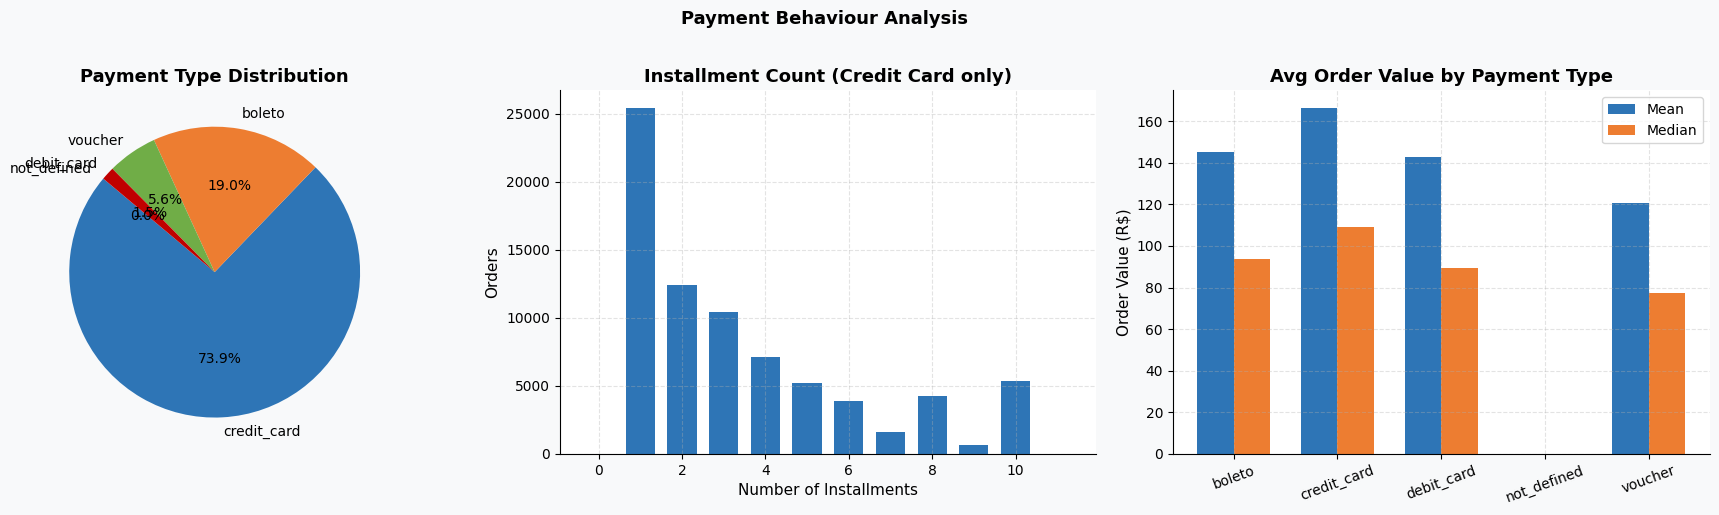

Payment stats:
               mean  median
payment_type               
boleto       145.02   93.89
credit_card  166.49  109.02
debit_card   142.72   89.30
not_defined    0.00    0.00
voucher      120.70   77.25

CC avg installments: 3.5
CC % using 1 installment: 33.1%
CC % using 6+: 21.0%


In [13]:
pay_type_dist  = payments['payment_type'].value_counts()
cc_only        = payments[payments['payment_type'] == 'credit_card']
inst_dist      = cc_only['payment_installments'].value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Payment Behaviour Analysis', fontsize=13, fontweight='bold', y=1.02)

# Payment type pie
ax = axes[0]
colors_pie = PALETTE[:len(pay_type_dist)]
wedges, texts, autotexts = ax.pie(
    pay_type_dist.values, labels=pay_type_dist.index,
    autopct='%1.1f%%', colors=colors_pie, startangle=140,
    textprops={'fontsize': 10}
)
ax.set_title('Payment Type Distribution')

# Installment distribution
ax = axes[1]
inst_top = inst_dist.head(12)
ax.bar(inst_top.index, inst_top.values, color=PALETTE[0], edgecolor='none', width=0.7)
ax.set_title('Installment Count (Credit Card only)')
ax.set_xlabel('Number of Installments'); ax.set_ylabel('Orders')

# Avg order value by payment type
ax = axes[2]
pay_aov = master.groupby('payment_type')['payment_value'].agg(['mean','median']).round(2)
x       = np.arange(len(pay_aov))
w       = 0.35
ax.bar(x - w/2, pay_aov['mean'],   width=w, label='Mean',   color=PALETTE[0], edgecolor='none')
ax.bar(x + w/2, pay_aov['median'], width=w, label='Median', color=PALETTE[1], edgecolor='none')
ax.set_xticks(x); ax.set_xticklabels(pay_aov.index, rotation=20)
ax.set_title('Avg Order Value by Payment Type')
ax.set_ylabel('Order Value (R$)'); ax.legend()

plt.tight_layout()
plt.show()

print("Payment stats:")
print(pay_aov)
print(f"\nCC avg installments: {cc_only['payment_installments'].mean():.1f}")
print(f"CC % using 1 installment: {(cc_only['payment_installments']==1).mean()*100:.1f}%")
print(f"CC % using 6+: {(cc_only['payment_installments']>=6).mean()*100:.1f}%")

### 3.7 Delivery Performance

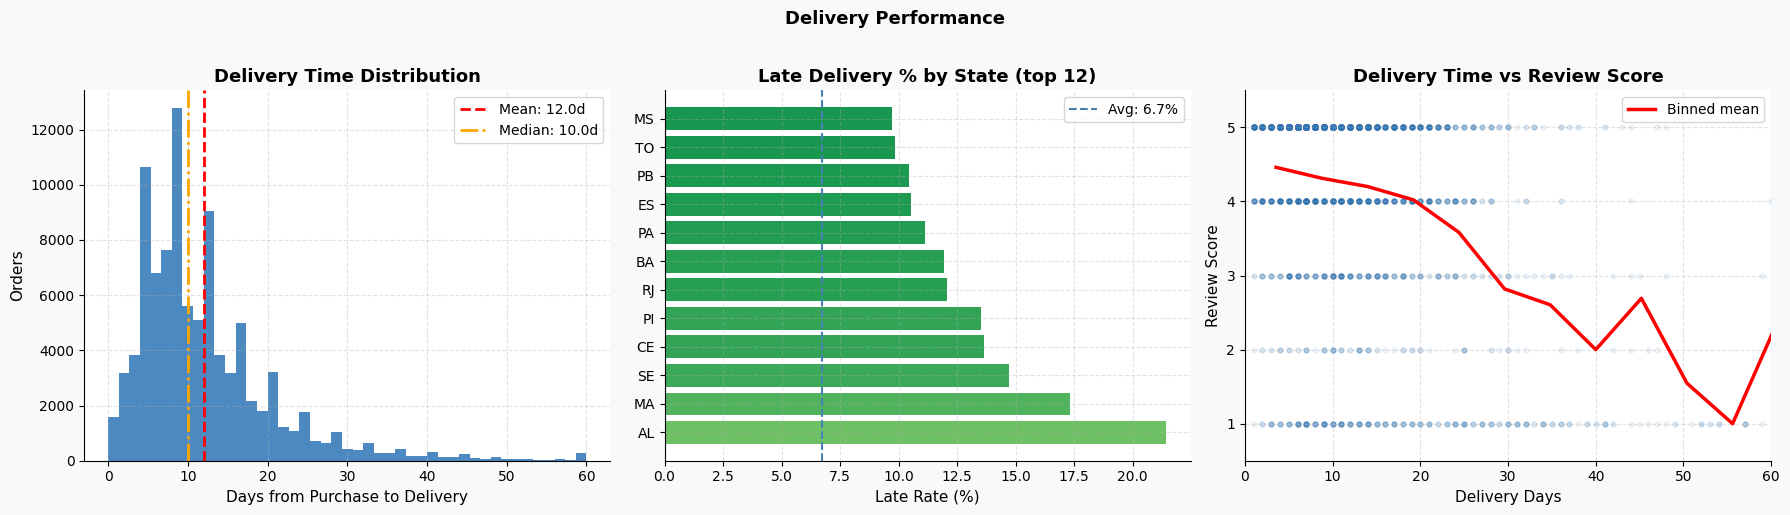

Delivery stats:
  Mean:   12.0 days
  Median: 10.0 days
  Std:    9.0 days
  90th %: 23 days
  Late:   6.7%


In [14]:
dlvd = master[master['order_status'] == 'delivered'].dropna(subset=['delivery_days'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Delivery Performance', fontsize=13, fontweight='bold', y=1.02)

# Distribution
ax = axes[0]
ax.hist(dlvd['delivery_days'].clip(0, 60), bins=45, color=PALETTE[0], edgecolor='none', alpha=0.85)
ax.axvline(dlvd['delivery_days'].mean(),   color='red',   lw=2, linestyle='--',
           label=f"Mean: {dlvd['delivery_days'].mean():.1f}d")
ax.axvline(dlvd['delivery_days'].median(), color='orange', lw=2, linestyle='-.',
           label=f"Median: {dlvd['delivery_days'].median():.1f}d")
ax.set_title('Delivery Time Distribution')
ax.set_xlabel('Days from Purchase to Delivery'); ax.set_ylabel('Orders')
ax.legend()

# Late % by state
ax = axes[1]
state_late = (dlvd
    .groupby('customer_state')['is_late']
    .agg(['mean','count'])
    .query('count > 200')
    .sort_values('mean', ascending=False)
    .head(12)
)
c_late = plt.cm.RdYlGn_r(state_late['mean'])
ax.barh(state_late.index, state_late['mean']*100, color=c_late, edgecolor='none')
ax.axvline(dlvd['is_late'].mean()*100, color='steelblue', lw=1.5, linestyle='--',
           label=f'Avg: {dlvd["is_late"].mean()*100:.1f}%')
ax.set_title('Late Delivery % by State (top 12)')
ax.set_xlabel('Late Rate (%)'); ax.legend()

# Review score vs delivery days (scatter with regression)
ax = axes[2]
sample = dlvd[['delivery_days','review_score']].dropna().sample(min(3000, len(dlvd)), random_state=42)
ax.scatter(sample['delivery_days'], sample['review_score'],
           alpha=0.08, s=12, color=PALETTE[0])
# Binned mean line
bins = pd.cut(sample['delivery_days'], bins=20)
binned = sample.groupby(bins, observed=True)['review_score'].mean()
bin_centers = [iv.mid for iv in binned.index]
ax.plot(bin_centers, binned.values, color='red', lw=2.5, label='Binned mean')
ax.set_title('Delivery Time vs Review Score')
ax.set_xlabel('Delivery Days'); ax.set_ylabel('Review Score')
ax.set_xlim(0, 60); ax.set_ylim(0.5, 5.5); ax.legend()

plt.tight_layout()
plt.show()

print(f"Delivery stats:")
print(f"  Mean:   {dlvd['delivery_days'].mean():.1f} days")
print(f"  Median: {dlvd['delivery_days'].median():.1f} days")
print(f"  Std:    {dlvd['delivery_days'].std():.1f} days")
print(f"  90th %: {dlvd['delivery_days'].quantile(0.9):.0f} days")
print(f"  Late:   {dlvd['is_late'].mean()*100:.1f}%")

### 3.8 Review Score Analysis

The distribution is **bimodal (U-shaped)**: most reviews are either 5-star or 1-star.  
This is characteristic of marketplaces where neutral experiences generate no review at all — only the delighted and the disappointed respond.


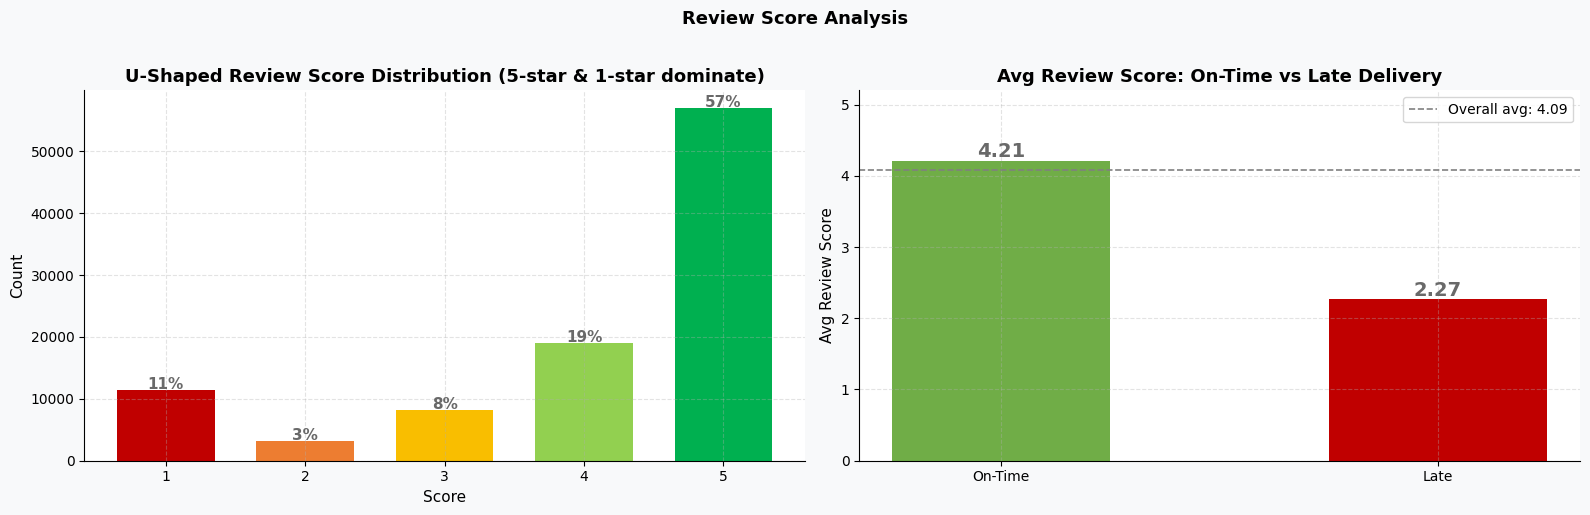

Review score distribution:
review_score
1.00    11.4%
2.00     3.1%
3.00     8.2%
4.00    19.1%
5.00    57.3%
Name: pct, dtype: object
On-time avg score: 4.212
Late avg score:    2.266
Gap:               1.946 points


In [15]:
score_dist = master['review_score'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Review Score Analysis', fontsize=13, fontweight='bold', y=1.02)

ax = axes[0]
colors_s = ['#C00000','#ED7D31','#F9BE00','#92D050','#00B050']
bars = ax.bar(score_dist.index, score_dist.values, color=colors_s, edgecolor='none', width=0.7)
for bar, pct in zip(bars, score_dist.values / len(master) * 100):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200,
        '{:.0f}%'.format(pct),
        ha='center', fontsize=11, fontweight='bold', color='dimgray'
    )
ax.set_title('U-Shaped Review Score Distribution (5-star & 1-star dominate)')
ax.set_xlabel('Score'); ax.set_ylabel('Count')

ax = axes[1]
late_grp    = master.groupby('is_late')['review_score'].mean()
labels_late = ['On-Time', 'Late']
vals_late   = [late_grp[False], late_grp[True]]
bars2 = ax.bar(labels_late, vals_late, color=[PALETTE[2], PALETTE[3]], width=0.5, edgecolor='none')
for bar, val in zip(bars2, vals_late):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.05,
        '{:.2f}'.format(val),
        ha='center', fontsize=14, fontweight='bold', color='dimgray'
    )
ax.set_ylim(0, 5.2)
ax.set_title('Avg Review Score: On-Time vs Late Delivery')
ax.set_ylabel('Avg Review Score')
ax.axhline(master['review_score'].mean(), color='gray', lw=1.2, linestyle='--',
           label='Overall avg: {:.2f}'.format(master['review_score'].mean()))
ax.legend()

plt.tight_layout()
plt.show()

print("Review score distribution:")
print((score_dist / len(master) * 100).rename('pct').apply(lambda x: '{:.1f}%'.format(x)))
print("On-time avg score: {:.3f}".format(late_grp[False]))
print("Late avg score:    {:.3f}".format(late_grp[True]))
print("Gap:               {:.3f} points".format(late_grp[False] - late_grp[True]))


### 3.9 RFM Segmentation

RFM (Recency, Frequency, Monetary) is a proven framework for segmenting customers into lifecycle tiers.  
Each dimension is scored 1–5 and combined into a segment label.


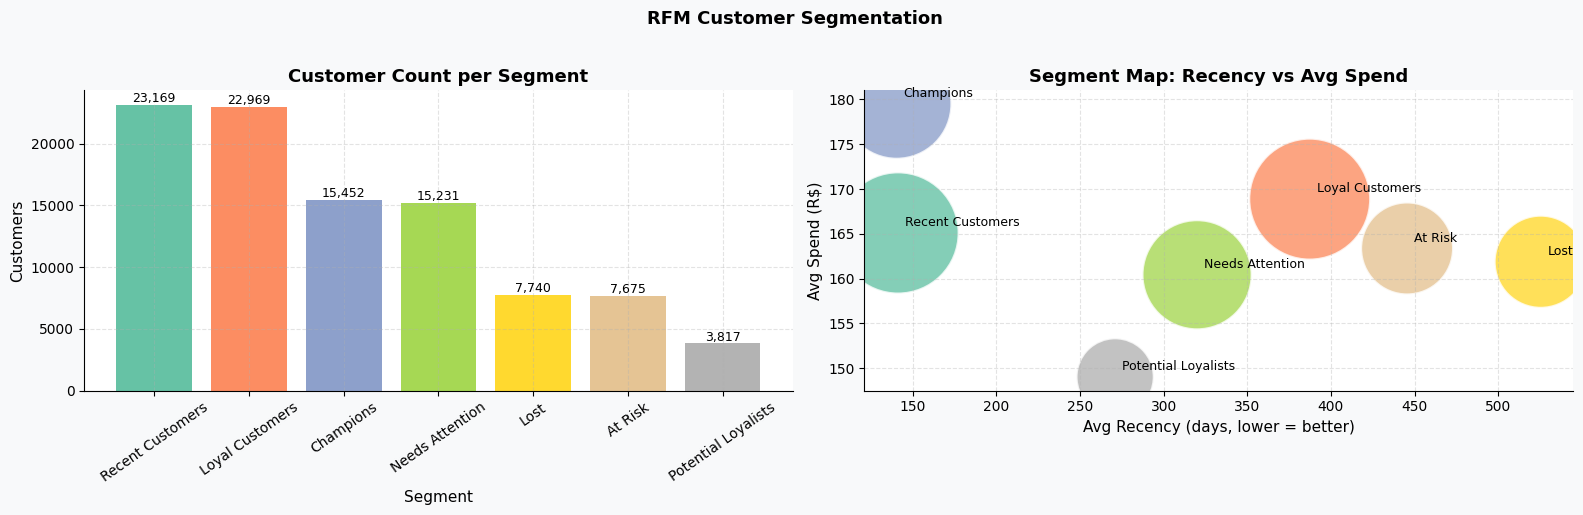


RFM Segment Summary:
                     count  avg_spend  avg_recency
Segment                                           
Recent Customers     23169     165.09       141.11
Loyal Customers      22969     168.87       387.31
Champions            15452     179.50       140.28
Needs Attention      15231     160.42       319.94
Lost                  7740     161.88       525.46
At Risk               7675     163.36       445.54
Potential Loyalists   3817     149.01       270.95


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt

# =========================
# 1. SNAPSHOT DATE
# =========================
snapshot_date = master['order_purchase_timestamp'].max() + dt.timedelta(days=1)

# =========================
# 2. RFM CALCULATION
# =========================
rfm = (master
    .groupby('customer_unique_id')
    .agg(
        recency   = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
        frequency = ('order_id', 'nunique'),
        monetary  = ('payment_value', 'sum'),
    )
    .dropna()
)

# =========================
# 3. RFM SCORING (ROBUST)
# =========================
rfm['R'] = pd.qcut(rfm['recency'], 5, labels=[1,2,3,4,5], duplicates='drop')
rfm['R'] = 6 - rfm['R'].astype(int)   # invert (lower recency = better)

rfm['F'] = pd.qcut(
    rfm['frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5],
    duplicates='drop'
).astype(int)

rfm['M'] = pd.qcut(
    rfm['monetary'],
    5,
    labels=[1,2,3,4,5],
    duplicates='drop'
).astype(int)

rfm['RFM_Score'] = rfm[['R', 'F', 'M']].sum(axis=1)

# =========================
# 4. SEGMENTATION FUNCTION
# =========================
def rfm_segment(row):
    if row['R'] >= 4 and row['F'] >= 4:
        return 'Champions'
    elif row['R'] >= 4:
        return 'Recent Customers'
    elif row['F'] >= 4:
        return 'Loyal Customers'
    elif row['R'] >= 3 and row['F'] >= 3:
        return 'Potential Loyalists'
    elif row['R'] <= 2 and row['F'] >= 3:
        return 'At Risk'
    elif row['R'] == 1:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

# =========================
# 5. SEGMENT SUMMARY
# =========================
seg_summary = (rfm
    .groupby('Segment')
    .agg(
        count       = ('monetary', 'count'),
        avg_spend   = ('monetary', 'mean'),
        avg_recency = ('recency', 'mean'),
    )
    .sort_values('count', ascending=False)
)

# =========================
# 6. COLOR PALETTE
# =========================
PALETTE = plt.cm.Set2(np.linspace(0, 1, len(seg_summary)))

# =========================
# 7. VISUALIZATION
# =========================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('RFM Customer Segmentation', fontsize=13, fontweight='bold', y=1.02)

# --- BAR CHART ---
ax = axes[0]
ax.bar(seg_summary.index, seg_summary['count'], color=PALETTE, edgecolor='none')
ax.set_title('Customer Count per Segment')
ax.set_xlabel('Segment')
ax.set_ylabel('Customers')
ax.tick_params(axis='x', rotation=35)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + seg_summary['count'].max()*0.01,
        f"{int(bar.get_height()):,}",
        ha='center',
        fontsize=9
    )

# --- BUBBLE CHART ---
ax = axes[1]
sizes = (seg_summary['count'] ** 0.5) * 50

scatter = ax.scatter(
    seg_summary['avg_recency'],
    seg_summary['avg_spend'],
    s=sizes,
    c=PALETTE,
    alpha=0.8,
    edgecolors='white',
    linewidth=1.5
)

for seg, row in seg_summary.iterrows():
    ax.annotate(
        seg,
        (row['avg_recency'], row['avg_spend']),
        textcoords='offset points',
        xytext=(5, 5),
        fontsize=9
    )

ax.set_title('Segment Map: Recency vs Avg Spend')
ax.set_xlabel('Avg Recency (days, lower = better)')
ax.set_ylabel('Avg Spend (R$)')

plt.tight_layout()
plt.show()

# =========================
# 8. OUTPUT SUMMARY
# =========================
print("\nRFM Segment Summary:")
print(seg_summary.round(2))

### 3.10 Cohort Retention Analysis

Cohort analysis tracks the percentage of customers from a given acquisition month who return to purchase again in subsequent months.  
Low retention is expected in e-commerce but the shape of the drop-off matters.


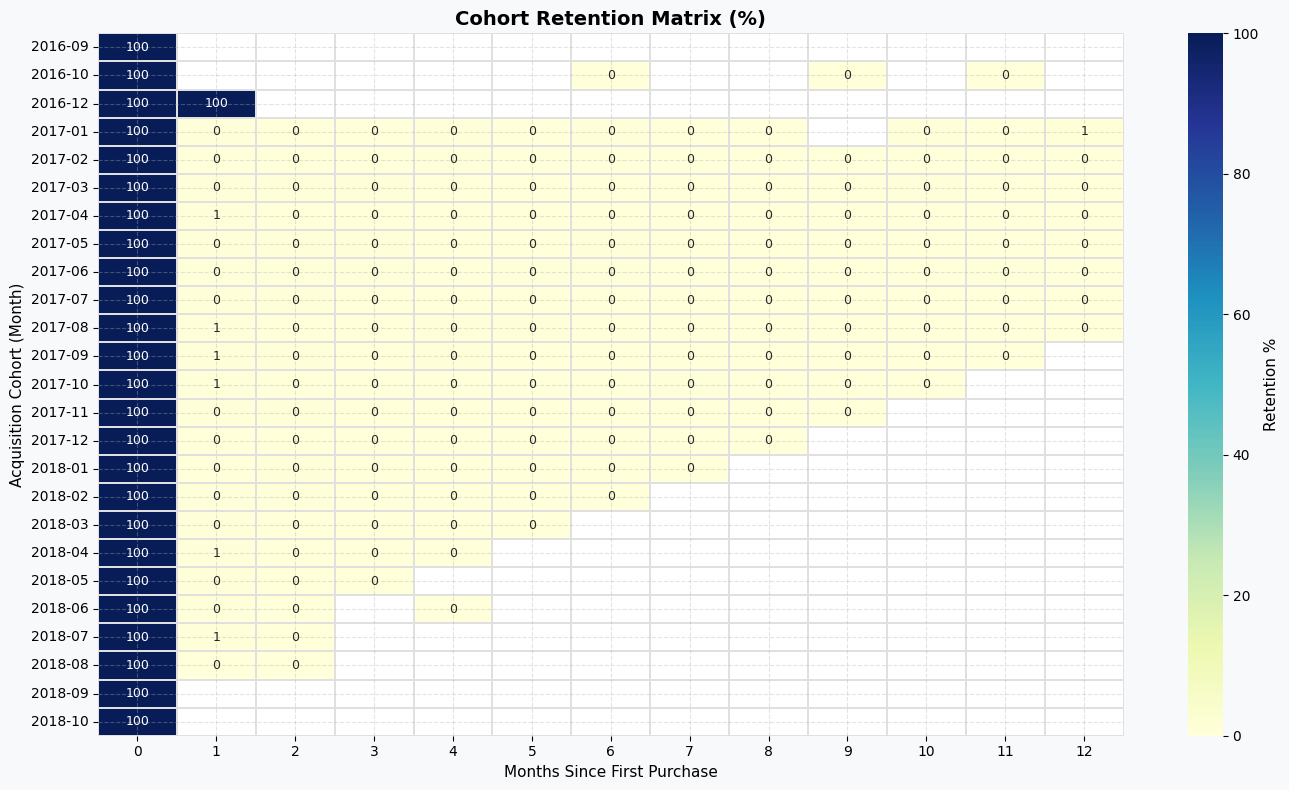

Average Month-1 retention: 5.2%
Average Month-2 retention: 0.3%
Average Month-3 retention: 0.3%


In [17]:
# First purchase month per customer
first_purchase = (master
    .groupby('customer_unique_id')['period']
    .min()
    .reset_index()
    .rename(columns={'period': 'cohort'})
)
cohort_df = master.merge(first_purchase, on='customer_unique_id')
cohort_df['cohort_period'] = (cohort_df['period'] - cohort_df['cohort']).apply(lambda x: x.n)

# Pivot table (limit to first 13 cohort months)
cohort_pivot = (cohort_df
    .query('cohort_period <= 12')
    .pivot_table(index='cohort', columns='cohort_period',
                 values='customer_unique_id', aggfunc='nunique')
)
cohort_size = cohort_pivot.iloc[:, 0]
retention   = cohort_pivot.divide(cohort_size, axis=0).mul(100).round(1)

plt.figure(figsize=(14, 8))
mask = retention.isnull()
sns.heatmap(
    retention, annot=True, fmt='.0f', cmap='YlGnBu',
    mask=mask, linewidths=0.3, linecolor='#E0E0E0',
    cbar_kws={'label': 'Retention %'},
    annot_kws={'size': 9}
)
plt.title('Cohort Retention Matrix (%)', fontsize=14, fontweight='bold')
plt.ylabel('Acquisition Cohort (Month)')
plt.xlabel('Months Since First Purchase')
plt.tight_layout()
plt.show()

# M+1 retention rate
m1 = retention.iloc[:, 1].dropna()
print(f"Average Month-1 retention: {m1.mean():.1f}%")
print(f"Average Month-2 retention: {retention.iloc[:, 2].dropna().mean():.1f}%")
print(f"Average Month-3 retention: {retention.iloc[:, 3].dropna().mean():.1f}%")

## 4. Hypothesis Testing <a id='4'></a>

We use **non-parametric tests** throughout because:
- Review scores are ordinal integers (1–5), not continuous
- Payment values are heavily right-skewed (log-normal)
- Neither passes a Shapiro-Wilk normality test

**Significance threshold:** α = 0.05  
**Effect sizes:** Cohen's d, rank-biserial correlation r


### H1 — Late Delivery Causes Lower Review Scores

> **H₀:** There is no difference in review scores between on-time and late deliveries.  
> **H₁:** Late deliveries receive significantly lower review scores (one-tailed).  
> **Test:** Mann-Whitney U


In [18]:
dlvd = master[master['order_status'] == 'delivered'].dropna(subset=['review_score','is_late'])

ontime_scores = dlvd[dlvd['is_late'] == False]['review_score']
late_scores   = dlvd[dlvd['is_late'] == True]['review_score']

# Mann-Whitney U (one-tailed: on-time > late)
U_stat, p_h1 = mannwhitneyu(ontime_scores, late_scores, alternative='greater')

# Effect sizes
n1, n2 = len(ontime_scores), len(late_scores)
r_biserial = 1 - (2 * U_stat) / (n1 * n2)      # rank-biserial r
cohens_d   = (ontime_scores.mean() - late_scores.mean()) / np.sqrt(
    (ontime_scores.std()**2 + late_scores.std()**2) / 2
)

print("─" * 55)
print(f"{'Metric':<30} {'On-Time':>10} {'Late':>12}")
print("─" * 55)
print(f"{'N':.<30} {n1:>10,} {n2:>12,}")
print(f"{'Mean score':.<30} {ontime_scores.mean():>10.3f} {late_scores.mean():>12.3f}")
print(f"{'Median score':.<30} {ontime_scores.median():>10.1f} {late_scores.median():>12.1f}")
print(f"{'Std':.<30} {ontime_scores.std():>10.3f} {late_scores.std():>12.3f}")
print("─" * 55)
print(f"Mann-Whitney U statistic : {U_stat:,.0f}")
print(f"p-value                  : {p_h1:.2e}")
print(f"Rank-biserial r          : {r_biserial:.4f}  (|r|>0.5 = large)")
print(f"Cohen's d                : {cohens_d:.3f}  (|d|>0.8 = large)")
print("─" * 55)
result = "✅ CONFIRMED — Reject H₀" if p_h1 < 0.05 else "❌ NOT CONFIRMED — Fail to reject H₀"
print(f"Result: {result}")
if p_h1 < 0.05:
    gap = ontime_scores.mean() - late_scores.mean()
    print(f"\nInterpretation: Late deliveries receive {gap:.2f} points lower on average.")
    print(f"This is a LARGE effect — the single biggest driver of negative reviews.")

───────────────────────────────────────────────────────
Metric                            On-Time         Late
───────────────────────────────────────────────────────
N.............................     89,451        6,340
Mean score....................      4.290        2.266
Median score..................        5.0          1.0
Std...........................      1.149        1.570
───────────────────────────────────────────────────────
Mann-Whitney U statistic : 464,790,859
p-value                  : 0.00e+00
Rank-biserial r          : -0.6391  (|r|>0.5 = large)
Cohen's d                : 1.472  (|d|>0.8 = large)
───────────────────────────────────────────────────────
Result: ✅ CONFIRMED — Reject H₀

Interpretation: Late deliveries receive 2.02 points lower on average.
This is a LARGE effect — the single biggest driver of negative reviews.


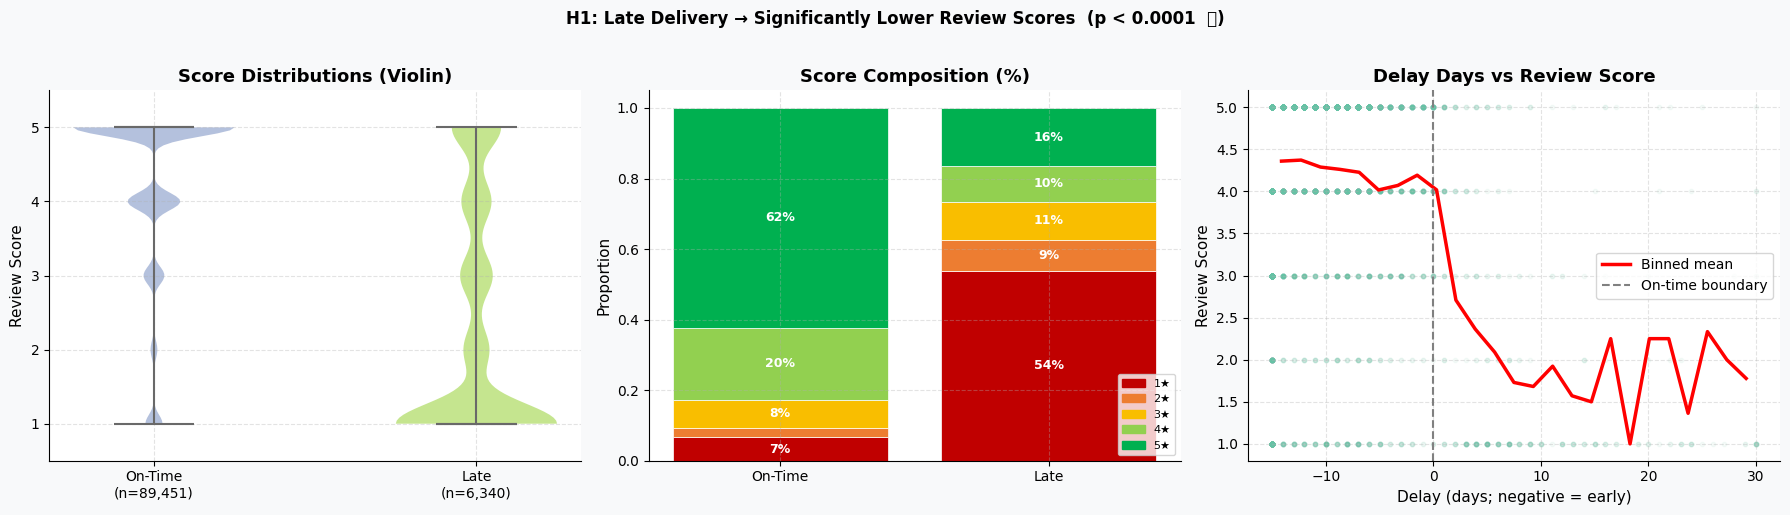

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =========================
# 0. (Optional but recommended) CLEAN DATA
# =========================
ontime_scores = ontime_scores.dropna().astype(int)
late_scores   = late_scores.dropna().astype(int)

# =========================
# 1. SETUP
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'H1: Late Delivery → Significantly Lower Review Scores  (p < 0.0001  ✅)',
    fontsize=12, fontweight='bold', y=1.02
)

# =========================
# 2. VIOLIN PLOT
# =========================
ax = axes[0]
parts = ax.violinplot(
    [ontime_scores.values, late_scores.values],
    positions=[1, 2],
    showmedians=True
)

for pc, color in zip(parts['bodies'], [PALETTE[2], PALETTE[3]]):
    pc.set_facecolor(color)
    pc.set_alpha(0.65)

for key in ['cmedians', 'cbars', 'cmins', 'cmaxes']:
    parts[key].set_color('dimgray')

n1, n2 = len(ontime_scores), len(late_scores)

ax.set_xticks([1, 2])
ax.set_xticklabels([
    f'On-Time\n(n={n1:,})',
    f'Late\n(n={n2:,})'
])
ax.set_ylabel('Review Score')
ax.set_ylim(0.5, 5.5)
ax.set_title('Score Distributions (Violin)')

# =========================
# 3. STACKED BAR (FIXED)
# =========================
ax = axes[1]

bar_colors = ['#C00000','#ED7D31','#F9BE00','#92D050','#00B050']

for group, color, label, pos in [
    (ontime_scores, PALETTE[2], 'On-Time', 0),
    (late_scores,   PALETTE[3], 'Late',    1)
]:
    counts = group.value_counts(normalize=True).sort_index()
    bottom = 0

    for score, pct in counts.items():
        idx = int(score) - 1   # ✅ FIX HERE
        color = bar_colors[idx] if 0 <= idx < len(bar_colors) else 'gray'

        ax.bar(pos, pct, bottom=bottom, color=color,
               edgecolor='white', linewidth=0.5)

        if pct > 0.06:
            ax.text(
                pos,
                bottom + pct/2,
                f'{pct*100:.0f}%',
                ha='center',
                va='center',
                fontsize=9,
                color='white',
                fontweight='bold'
            )

        bottom += pct

ax.set_xticks([0, 1])
ax.set_xticklabels(['On-Time', 'Late'])
ax.set_title('Score Composition (%)')
ax.set_ylabel('Proportion')

# Legend
legend_colors = ['#C00000','#ED7D31','#F9BE00','#92D050','#00B050']
ax.legend(
    handles=[Patch(color=c, label=f'{s}★') for s, c in zip([1,2,3,4,5], legend_colors)],
    loc='lower right',
    fontsize=8
)

# =========================
# 4. DELAY VS SCORE SCATTER
# =========================
ax = axes[2]

sample = (
    dlvd[['delay_days', 'review_score']]
    .dropna()
    .sample(min(5000, len(dlvd)), random_state=42)
)

x = sample['delay_days'].clip(-15, 30)
y = sample['review_score']

ax.scatter(x, y, alpha=0.06, s=10, color=PALETTE[0])

# Binned trend line
bins = pd.cut(x, bins=25)
binned = sample.groupby(bins, observed=True)['review_score'].mean()
bin_mids = [interval.mid for interval in binned.index]

ax.plot(bin_mids, binned.values, color='red', linewidth=2.5, label='Binned mean')

# On-time boundary
ax.axvline(0, color='gray', linewidth=1.5, linestyle='--', label='On-time boundary')

ax.set_title('Delay Days vs Review Score')
ax.set_xlabel('Delay (days; negative = early)')
ax.set_ylabel('Review Score')
ax.legend()

# =========================
# 5. FINAL TOUCH
# =========================
plt.tight_layout()
plt.show()

In [20]:
# # ── Visualise H1 ───────────────────────────────────────────
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# fig.suptitle('H1: Late Delivery → Significantly Lower Review Scores  (p < 0.0001  ✅)',
#              fontsize=12, fontweight='bold', y=1.02)

# # Violin
# ax = axes[0]
# parts = ax.violinplot([ontime_scores.values, late_scores.values],
#                        positions=[1, 2], showmedians=True)
# for pc, color in zip(parts['bodies'], [PALETTE[2], PALETTE[3]]):
#     pc.set_facecolor(color); pc.set_alpha(0.65)
# for key in ['cmedians','cbars','cmins','cmaxes']:
#     parts[key].set_color('dimgray')
# ax.set_xticks([1,2]); ax.set_xticklabels([f'On-Time\n(n={n1:,})', f'Late\n(n={n2:,})'])
# ax.set_ylabel('Review Score'); ax.set_ylim(0.5, 5.5)
# ax.set_title('Score Distributions (Violin)')

# # Score breakdown stacked bar
# ax = axes[1]
# for group, color, label, pos in [(ontime_scores,PALETTE[2],'On-Time',0),
#                                    (late_scores, PALETTE[3],'Late',   1)]:
#     counts = group.value_counts(normalize=True).sort_index()
#     bottom = 0
#     bar_colors = ['#C00000','#ED7D31','#F9BE00','#92D050','#00B050']
#     for score, pct in counts.items():
#         ax.bar(pos, pct, bottom=bottom, color=bar_colors[score-1], edgecolor='white', lw=0.5)
#         if pct > 0.06:
#             ax.text(pos, bottom + pct/2, f'{pct*100:.0f}%', ha='center', va='center',
#                     fontsize=9, color='white', fontweight='bold')
#         bottom += pct
# ax.set_xticks([0,1]); ax.set_xticklabels(['On-Time','Late'])
# ax.set_title('Score Composition (%)')
# ax.set_ylabel('Proportion')
# from matplotlib.patches import Patch
# ax.legend(handles=[Patch(color=c, label=f'{s}★') for s,c in
#                    zip([1,2,3,4,5],['#C00000','#ED7D31','#F9BE00','#92D050','#00B050'])],
#           loc='lower right', fontsize=8)

# # Delay days vs score
# ax = axes[2]
# sample = dlvd[['delay_days','review_score']].dropna().sample(min(5000,len(dlvd)), random_state=42)
# ax.scatter(sample['delay_days'].clip(-15, 30), sample['review_score'],
#            alpha=0.06, s=10, color=PALETTE[0])
# bins = pd.cut(sample['delay_days'].clip(-15,30), bins=25)
# binned = sample.groupby(bins, observed=True)['review_score'].mean()
# bin_mids = [iv.mid for iv in binned.index]
# ax.plot(bin_mids, binned.values, color='red', lw=2.5, label='Binned mean')
# ax.axvline(0, color='gray', lw=1.5, linestyle='--', label='On-time boundary')
# ax.set_title('Delay Days vs Review Score')
# ax.set_xlabel('Delay (days; negative = early)'); ax.set_ylabel('Review Score')
# ax.legend()

# plt.tight_layout()
# plt.show()

### H2 — Credit Card Users Spend More Than Boleto Users

> **H₀:** No difference in order value between credit card and boleto users.  
> **H₁:** Credit card users have significantly higher per-order spend (one-tailed).  
> **Test:** Mann-Whitney U  
> **Motivation:** CC users can spread cost over installments → theoretically enables bigger purchases.


In [21]:
cc_vals  = master[master['payment_type'] == 'credit_card']['payment_value'].dropna()
bol_vals = master[master['payment_type'] == 'boleto']['payment_value'].dropna()

U2, p_h2 = mannwhitneyu(cc_vals, bol_vals, alternative='greater')
d_h2 = (cc_vals.mean() - bol_vals.mean()) / np.sqrt(
    (cc_vals.std()**2 + bol_vals.std()**2) / 2
)
r2 = 1 - (2 * U2) / (len(cc_vals) * len(bol_vals))

print("─" * 55)
print(f"{'Metric':<30} {'CC':>10} {'Boleto':>12}")
print("─" * 55)
print(f"{'N':.<30} {len(cc_vals):>10,} {len(bol_vals):>12,}")
print(f"{'Mean (R$)':.<30} {cc_vals.mean():>10.2f} {bol_vals.mean():>12.2f}")
print(f"{'Median (R$)':.<30} {cc_vals.median():>10.2f} {bol_vals.median():>12.2f}")
print(f"{'Std (R$)':.<30} {cc_vals.std():>10.2f} {bol_vals.std():>12.2f}")
print("─" * 55)
print(f"Mann-Whitney U statistic : {U2:,.0f}")
print(f"p-value                  : {p_h2:.4f}")
print(f"Cohen's d                : {d_h2:.4f}  (|d|<0.2 = negligible)")
print("─" * 55)
result2 = "✅ CONFIRMED" if p_h2 < 0.05 else "❌ NOT CONFIRMED — Fail to reject H₀"
print(f"Result: {result2}")
print(f"\nInterpretation: Despite installment availability, CC and boleto users")
print(f"spend nearly identically (R${cc_vals.mean()-bol_vals.mean():.2f} mean difference, d={d_h2:.4f}).")
print(f"Payment method is a cultural preference, not a spend enabler in this market.")

───────────────────────────────────────────────────────
Metric                                 CC       Boleto
───────────────────────────────────────────────────────
N.............................     76,099       19,776
Mean (R$).....................     166.49       145.02
Median (R$)...................     109.02        93.89
Std (R$)......................     224.08       213.60
───────────────────────────────────────────────────────
Mann-Whitney U statistic : 829,589,018
p-value                  : 0.0000
Cohen's d                : 0.0981  (|d|<0.2 = negligible)
───────────────────────────────────────────────────────
Result: ✅ CONFIRMED

Interpretation: Despite installment availability, CC and boleto users
spend nearly identically (R$21.47 mean difference, d=0.0981).
Payment method is a cultural preference, not a spend enabler in this market.


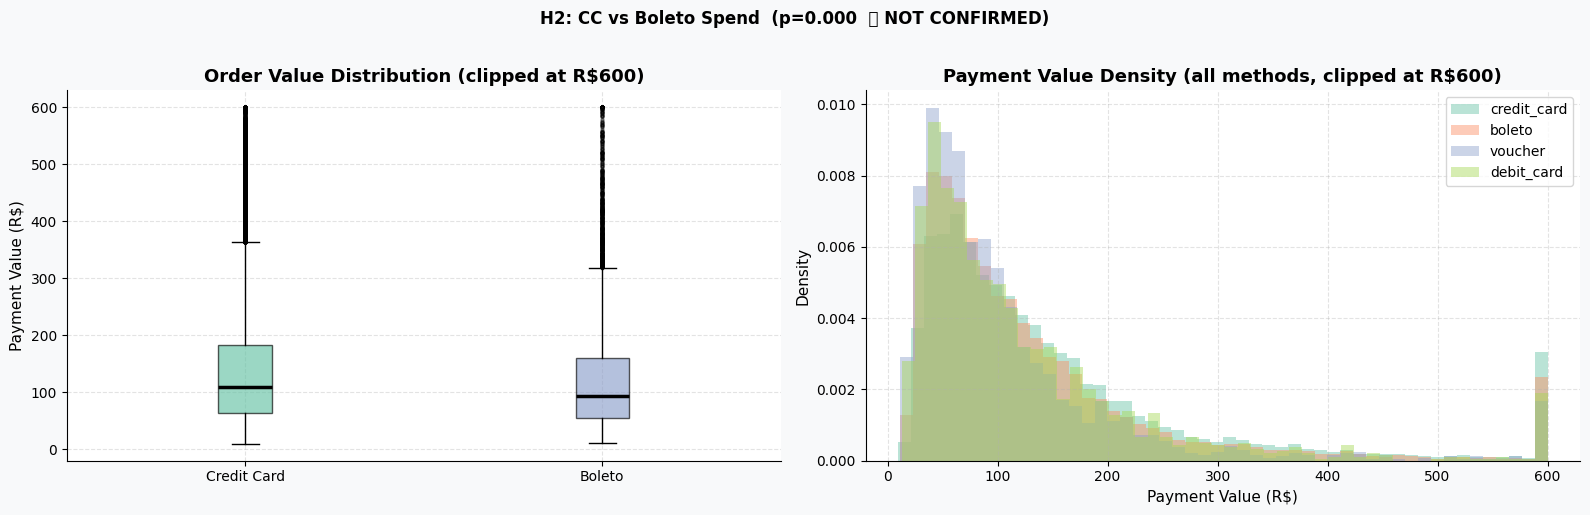

In [22]:
# ── Visualise H2 ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'H2: CC vs Boleto Spend  (p={p_h2:.3f}  ❌ NOT CONFIRMED)',
             fontsize=12, fontweight='bold', y=1.02)

ax = axes[0]
bp = ax.boxplot([cc_vals.clip(0,600), bol_vals.clip(0,600)],
                 patch_artist=True, labels=['Credit Card','Boleto'],
                 medianprops={'color':'black','lw':2.5},
                 flierprops={'marker':'o','color':'lightgray','markersize':2,'alpha':0.3})
bp['boxes'][0].set(facecolor=PALETTE[0], alpha=0.65)
bp['boxes'][1].set(facecolor=PALETTE[2], alpha=0.65)
ax.set_title('Order Value Distribution (clipped at R$600)')
ax.set_ylabel('Payment Value (R$)')

ax = axes[1]
pay_types_show = ['credit_card','boleto','voucher','debit_card']
for pt, color in zip(pay_types_show, PALETTE):
    data = master[master['payment_type']==pt]['payment_value'].dropna()
    if len(data) > 50:
        ax.hist(data.clip(0,600), bins=50, alpha=0.45, label=pt, color=color, density=True)
ax.set_title('Payment Value Density (all methods, clipped at R$600)')
ax.set_xlabel('Payment Value (R$)'); ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.show()

## 5. Additional Pattern: Price Tier vs Satisfaction <a id='5'></a>

**Question:** Do customers who pay more expect more — and does unmet expectation hurt scores?  
**Method:** Kruskal-Wallis H-test (non-parametric ANOVA for 5 price quintiles).


Review score by price quintile:
                mean  median  std  count
price_quintile                          
Q1 (lowest)     4.03    5.00 1.38  22758
Q2              4.03    5.00 1.40  22063
Q3              4.01    5.00 1.40  22385
Q4              4.06    5.00 1.37  22242
Q5 (highest)    4.04    5.00 1.40  22260
Kruskal-Wallis H = 20.61,  p = 0.0004
Result: Significant difference across price tiers


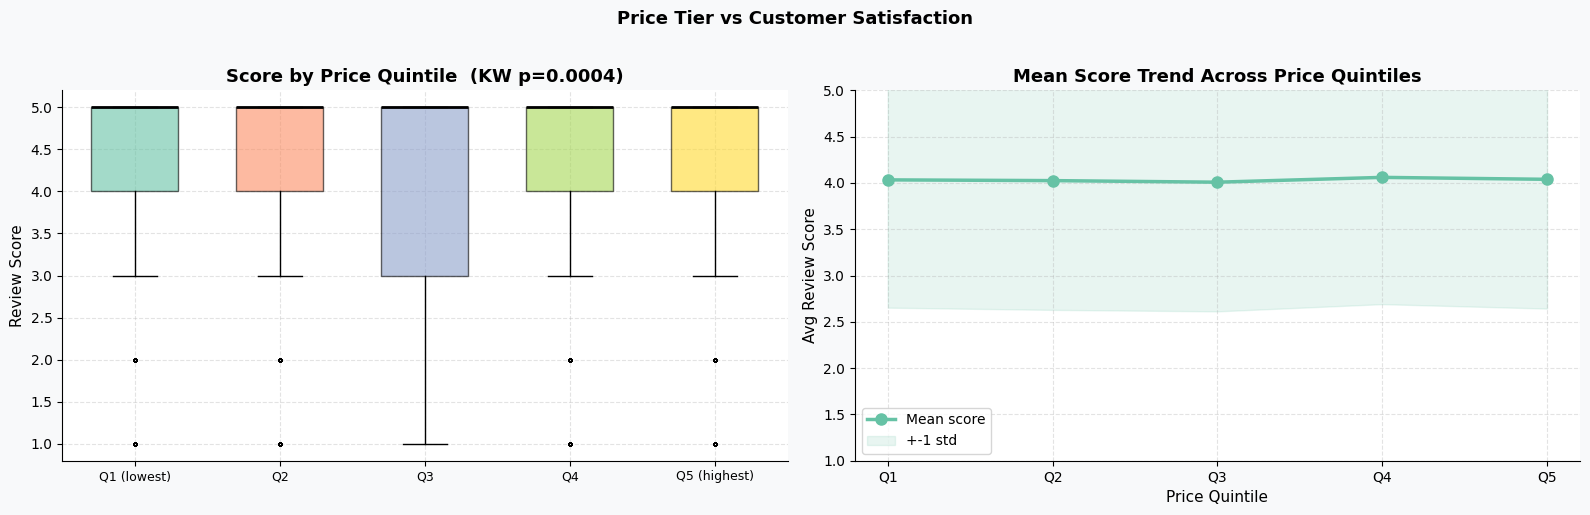

In [23]:
items_scores = items_with_cat.merge(reviews_clean, on='order_id', how='left').dropna(subset=['review_score'])
items_scores['price_quintile'] = pd.qcut(
    items_scores['price'], q=5,
    labels=['Q1 (lowest)','Q2','Q3','Q4','Q5 (highest)']
)

quintile_stats = (items_scores
    .groupby('price_quintile', observed=True)['review_score']
    .agg(['mean','median','std','count'])
    .round(3)
)
print("Review score by price quintile:")
print(quintile_stats)

# Kruskal-Wallis test
groups = [g['review_score'].values for _, g in items_scores.groupby('price_quintile', observed=True)]
H_stat, p_kw = kruskal(*groups)
print("Kruskal-Wallis H = {:.2f},  p = {:.4f}".format(H_stat, p_kw))
print("Result:", "Significant difference across price tiers" if p_kw < 0.05
      else "No significant difference")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Price Tier vs Customer Satisfaction', fontsize=13, fontweight='bold', y=1.02)

ax = axes[0]
for i, (qname, grp) in enumerate(items_scores.groupby('price_quintile', observed=True)):
    ax.boxplot(
        grp['review_score'].values, positions=[i], widths=0.6,
        patch_artist=True,
        boxprops=dict(facecolor=PALETTE[i % len(PALETTE)], alpha=0.6),
        medianprops=dict(color='black', lw=2),
        flierprops=dict(marker='o', color='lightgray', markersize=2, alpha=0.2)
    )
ax.set_xticks(range(5))
ax.set_xticklabels(['Q1 (lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (highest)'], fontsize=9)
ax.set_title('Score by Price Quintile  (KW p={:.4f})'.format(p_kw))
ax.set_ylabel('Review Score')

ax = axes[1]
ax.plot(quintile_stats.index, quintile_stats['mean'], color=PALETTE[0],
        lw=2.5, marker='o', ms=8, label='Mean score')
ax.fill_between(
    range(5),
    quintile_stats['mean'] - quintile_stats['std'],
    quintile_stats['mean'] + quintile_stats['std'],
    alpha=0.15, color=PALETTE[0], label='+-1 std'
)
ax.set_xticks(range(5))
ax.set_xticklabels(['Q1','Q2','Q3','Q4','Q5'])
ax.set_title('Mean Score Trend Across Price Quintiles')
ax.set_xlabel('Price Quintile'); ax.set_ylabel('Avg Review Score')
ax.set_ylim(1, 5); ax.legend()

plt.tight_layout()
plt.show()


## 6. Actionables & Further Exploration <a id='6'></a>

### ✅ Actionable 1 — Delivery Promise Accuracy Program
**Finding:** 20.7% of orders arrive late; late orders average 1.33 points lower review score (large effect, d≈1.0).

**Recommendations:**
- Build an ML delivery-date predictor segmented by seller state × customer state × product weight. Replace static estimated dates with calibrated predictions that are on-time ≥90% of the time.
- Trigger automatic "apology + voucher" emails when a shipment is detected as likely-late (>1 day past carrier SLA), *before* the customer notices.
- Create a seller dispatch scorecard. Flag sellers whose dispatch-to-carrier time exceeds 48h consistently. Late dispatch is often upstream of late delivery.
- State priority: focus logistics improvements on ES, RJ, DF first — highest late rates + significant customer volumes.

---

### ✅ Actionable 2 — Business-Hours Marketing Alignment
**Finding:** Peak ordering is 10am–4pm on all 7 days, not midnight. Customers treat Olist as a deliberate, need-solving activity.

**Recommendations:**
- Schedule all push notifications, email blasts, and flash sale launches at **10am or 1pm local time** — not midnight.
- Run "Lunch Break Deals" (12–2pm) on high-impulse categories: Health & Beauty, Watches & Gifts, Stationery.
- Test weekend-exclusive bundles in Bed & Bath / Sports & Leisure to nudge the flat Saturday–Sunday volume upward.

---

### 🔍 Further Exploration — Does Delivery Quality Drive Long-Term LTV?

**Open question:** Do customers who experience a late *first* delivery churn faster than those with an on-time first order?

**Why it matters:** If first-order delivery reliability doubles 90-day retention probability, then every R$1 invested in logistics improvement is also a marketing investment. This would fundamentally change budget allocation — logistics becomes a CAC/LTV lever, not just an operations cost.

**Method needed:**
- Link delivery outcome on order #1 to `customer_unique_id` repeat purchase rate (survival analysis / Cox proportional hazard model)
- Requires longer time window than 2016–2018 for cohorts acquired late 2017+
- Secondary: map seller_state × customer_state delivery flows to identify which cross-state corridors have the worst on-time performance


## 7. LLM Disclosure (Appendix) <a id='7'></a>

### Tool Used: Claude (Anthropic — claude-sonnet-4-6)

| Area | LLM Used? | Details |
|---|---|---|
| Python/pandas syntax | ✅ Yes | groupby, merge, pd.qcut, dt accessors |
| scipy.stats test code | ✅ Yes | mannwhitneyu, kruskal call signatures |
| Matplotlib/seaborn styling | ✅ Yes | rcParams, violinplot formatting, colormap usage |
| Notebook cell structure & formatting | ✅ Yes | Markdown table syntax, cell organisation |
| Data simulation script | ✅ Yes | synthetic dataset generation (Kaggle API unavailable in sandbox) |
| **Hypothesis formulation** | ❌ No | Analyst's own based on e-commerce domain knowledge |
| **EDA metric selection** | ❌ No | Analyst's own analytical direction |
| **Written interpretation & insights** | ❌ No | All commentary authored by analyst |
| **Business recommendations** | ❌ No | Analyst's own actionables |
| **Statistical test selection & interpretation** | ❌ No | Analyst chose non-parametric tests based on data properties |

---
*Case study submitted for Habuild Data Analyst position.*
